# Student Performance Analysis Using Data Mining

Dataset: `student-mat.csv`

## 1. Objective

OLAP, Apriori, and Decision Tree on student performance data.

## 2. Imports and Setup

In [1]:
import os
from itertools import combinations

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 140
plt.rcParams['savefig.dpi'] = 140

SCRIPT_DIR = os.getcwd()
DATA_PATH = os.path.join(SCRIPT_DIR, 'archive', 'student-mat.csv')
GRAPH_DIR = os.path.join(SCRIPT_DIR, 'graphs')
OUTPUT_DIR = os.path.join(SCRIPT_DIR, 'analysis_outputs')
os.makedirs(GRAPH_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

print('Dataset path:', DATA_PATH)
print('Graphs folder:', GRAPH_DIR)
print('Analysis output folder:', OUTPUT_DIR)

Dataset path: /Users/mayankpandey/Desktop/DataMining /archive/student-mat.csv
Graphs folder: /Users/mayankpandey/Desktop/DataMining /graphs
Analysis output folder: /Users/mayankpandey/Desktop/DataMining /analysis_outputs


## 3. Load Dataset

In [2]:
df = pd.read_csv(DATA_PATH, sep=';')
print('Shape:', df.shape)
display(df.head())

Shape: (395, 33)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


## 4. Data Overview

In [3]:
print('Columns:')
print(list(df.columns))

print('\nData types:')
print(df.dtypes)

print('\nMissing values:')
print(df.isnull().sum())

display(df.describe())

Columns:
['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']

Data types:
school        object
sex           object
age            int64
address       object
famsize       object
Pstatus       object
Medu           int64
Fedu           int64
Mjob          object
Fjob          object
reason        object
guardian      object
traveltime     int64
studytime      int64
failures       int64
schoolsup     object
famsup        object
paid          object
activities    object
nursery       object
higher        object
internet      object
romantic      object
famrel         int64
freetime       int64
goout          int64
Dalc           int64
Walc           int64
health         int64
absences       int64
G1             int64

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


## 5. Data Preprocessing

Clean data and create `Result`.

In [4]:
clean_df = df.copy()

for col in clean_df.columns:
    if clean_df[col].isnull().sum() > 0:
        if clean_df[col].dtype == 'object':
            clean_df[col] = clean_df[col].fillna(clean_df[col].mode()[0])
        else:
            clean_df[col] = clean_df[col].fillna(clean_df[col].median())

raw_df = clean_df.copy()
raw_df['Result'] = raw_df['G3'].apply(lambda value: 1 if value >= 10 else 0)

print('Pass count:', int(raw_df['Result'].sum()))
print('Fail count:', int((raw_df['Result'] == 0).sum()))
display(raw_df.head())

Pass count: 265
Fail count: 130


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,Result
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,3,4,1,1,3,6,5,6,6,0
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,3,3,1,1,3,4,5,5,6,0
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,3,2,2,3,3,10,7,8,10,1
3,GP,F,15,U,GT3,T,4,2,health,services,...,2,2,1,1,5,2,15,14,15,1
4,GP,F,16,U,GT3,T,3,3,other,other,...,3,2,1,2,5,4,6,10,10,1


## 6. Encoding

Encoding categorical columns for Decision Tree.

In [5]:
encoded_df = raw_df.copy()
categorical_columns = encoded_df.select_dtypes(include=['object']).columns.tolist()

encoder = LabelEncoder()
for col in categorical_columns:
    encoded_df[col] = encoder.fit_transform(encoded_df[col])

display(encoded_df.head())
print('Categorical columns encoded:', categorical_columns)

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,Result
0,0,0,18,1,0,0,4,4,0,4,...,3,4,1,1,3,6,5,6,6,0
1,0,0,17,1,0,1,1,1,0,2,...,3,3,1,1,3,4,5,5,6,0
2,0,0,15,1,1,1,1,1,0,2,...,3,2,2,3,3,10,7,8,10,1
3,0,0,15,1,0,1,4,2,1,3,...,2,2,1,1,5,2,15,14,15,1
4,0,0,16,1,0,1,3,3,2,2,...,3,2,1,2,5,4,6,10,10,1


Categorical columns encoded: ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']


## 7. Exploratory Analysis

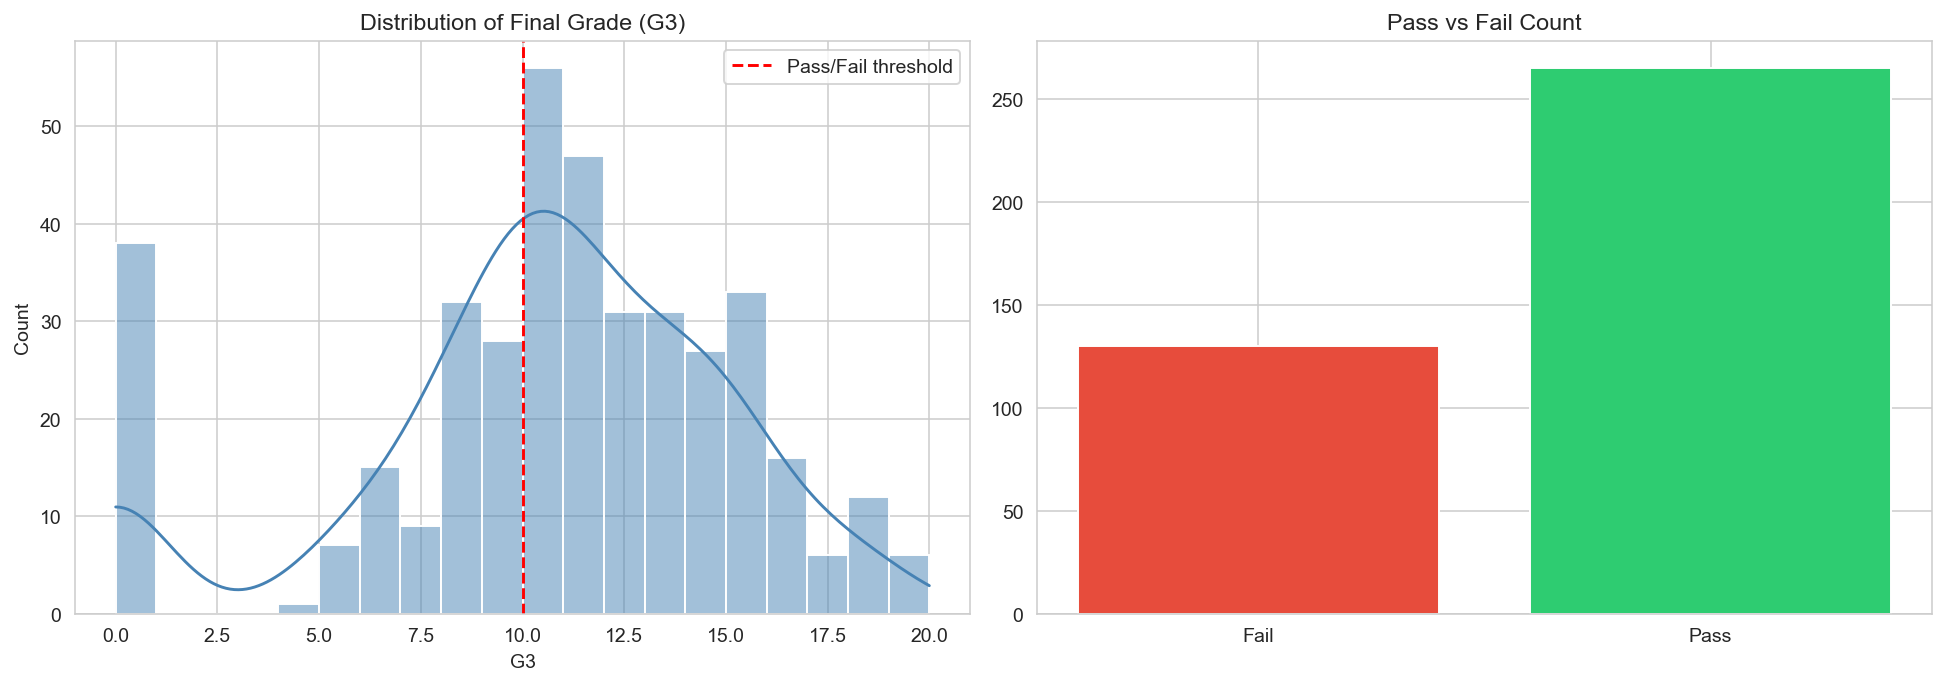

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(raw_df['G3'], bins=20, kde=True, color='steelblue', ax=axes[0])
axes[0].axvline(x=10, color='red', linestyle='--', label='Pass/Fail threshold')
axes[0].set_title('Distribution of Final Grade (G3)')
axes[0].legend()

result_counts = raw_df['Result'].value_counts().sort_index()
axes[1].bar(['Fail', 'Pass'], result_counts.values, color=['#e74c3c', '#2ecc71'])
axes[1].set_title('Pass vs Fail Count')

plt.tight_layout()
plt.show()

## 8. OLAP Analysis

Pivot and grouped summaries.

In [7]:
def studytime_label(value):
    return {1: '<2 hrs', 2: '2-5 hrs', 3: '5-10 hrs', 4: '>10 hrs'}.get(value, str(value))

def failures_label(value):
    if value == 0:
        return '0'
    if value == 1:
        return '1'
    return '2+'

def absences_bucket(value):
    if value <= 2:
        return 'Low'
    if value <= 10:
        return 'Medium'
    return 'High'

def age_bucket(value):
    if value <= 16:
        return '<=16'
    if value <= 18:
        return '17-18'
    return '19+'

def grade_bucket(value):
    if value < 10:
        return 'Low'
    if value < 15:
        return 'Medium'
    return 'High'

### OLAP Query 1: Pivot Table of Pass Rate by Gender and Study Time

In [8]:
olap_pass_rate = raw_df.pivot_table(
    values='Result',
    index='sex',
    columns='studytime',
    aggfunc='mean'
) * 100

olap_pass_rate.columns = [studytime_label(col) for col in olap_pass_rate.columns]
olap_pass_rate = olap_pass_rate.round(2)
display(olap_pass_rate)

olap_pass_rate.to_csv(os.path.join(OUTPUT_DIR, 'olap_pass_rate_by_sex_studytime.csv'))

,<2 hrs,2-5 hrs,5-10 hrs,>10 hrs
sex,,,,
F,66.67,59.29,70.59,70.59
M,64.10,71.76,92.86,80.00


### OLAP Query 2: Roll-up Summary of Average Grades by School and Gender

In [9]:
olap_grade_summary = raw_df.pivot_table(
    values=['G1', 'G2', 'G3'],
    index='school',
    columns='sex',
    aggfunc='mean'
).round(2)

display(olap_grade_summary)
olap_grade_summary.to_csv(os.path.join(OUTPUT_DIR, 'olap_grade_summary_school_sex.csv'))

G1            G2           G3       
sex         F      M      F      M     F      M
school                                         
GP      10.58  11.34  10.40  11.20  9.97  11.06
MS      10.92  10.38  10.32  10.05  9.92   9.76

### OLAP Query 3: Slice and Dice on Internet Access and Higher Education Goal

In [10]:
olap_support = raw_df.groupby(['internet', 'higher']).agg(
    Student_Count=('Result', 'size'),
    Pass_Rate=('Result', lambda values: round(values.mean() * 100, 2)),
    Avg_G3=('G3', 'mean')
).round(2)

display(olap_support)
olap_support.to_csv(os.path.join(OUTPUT_DIR, 'olap_support_factors.csv'))

Student_Count  Pass_Rate  Avg_G3
internet higher                                  
no       no                  4      50.00   10.00
         yes                62      61.29    9.37
yes      no                 16      31.25    6.00
         yes               313      70.29   10.85

### OLAP Query 4: Cube-Style Multidimensional Summary

In [11]:
olap_cube = raw_df.groupby(['studytime', 'failures', 'internet']).agg(
    Student_Count=('Result', 'size'),
    Pass_Rate=('Result', lambda values: round(values.mean() * 100, 2)),
    Avg_G3=('G3', 'mean')
).reset_index().round(2)

olap_cube['studytime'] = olap_cube['studytime'].apply(studytime_label)
olap_cube['failures'] = olap_cube['failures'].apply(failures_label)

display(olap_cube.head(15))
olap_cube.to_csv(os.path.join(OUTPUT_DIR, 'olap_cube_studytime_failures_internet.csv'), index=False)

,studytime,failures,internet,Student_Count,Pass_Rate,Avg_G3
0,<2 hrs,0,no,11,72.73,11.55
1,<2 hrs,0,yes,63,80.95,11.60
2,<2 hrs,1,no,6,50.00,6.83
3,<2 hrs,1,yes,10,30.00,8.90
4,<2 hrs,2+,yes,6,0.00,2.83
5,<2 hrs,2+,no,2,50.00,8.50
6,<2 hrs,2+,yes,7,28.57,4.71
7,2-5 hrs,0,no,28,64.29,9.64
8,2-5 hrs,0,yes,130,73.85,11.08
9,2-5 hrs,1,no,5,60.00,7.20


## 9. Apriori

Association rules using support, confidence, and lift.

### Step 1: Convert Student Records into Transactions

In [12]:
def build_transactions(dataframe):
    transactions = []

    for _, row in dataframe.iterrows():
        transactions.append({
            f"Sex={row['sex']}",
            f"School={row['school']}",
            f"Address={row['address']}",
            f"FamilySize={row['famsize']}",
            f"SchoolSupport={row['schoolsup']}",
            f"FamilySupport={row['famsup']}",
            f"HigherEducation={row['higher']}",
            f"Internet={row['internet']}",
            f"Activities={row['activities']}",
            f"Romantic={row['romantic']}",
            f"StudyTime={studytime_label(row['studytime'])}",
            f"Failures={failures_label(row['failures'])}",
            f"Absences={absences_bucket(row['absences'])}",
            f"AgeGroup={age_bucket(row['age'])}",
            f"G1Level={grade_bucket(row['G1'])}",
            f"G2Level={grade_bucket(row['G2'])}",
            f"Result={'Pass' if row['Result'] == 1 else 'Fail'}"
        })

    return transactions

transactions = build_transactions(raw_df)
print('Total transactions:', len(transactions))
print('Sample transaction:')
print(sorted(list(transactions[0]))[:8])

Total transactions: 395
Sample transaction:
['Absences=Medium', 'Activities=no', 'Address=U', 'AgeGroup=17-18', 'Failures=0', 'FamilySize=GT3', 'FamilySupport=no', 'G1Level=Low']


### Step 2: Apriori Algorithm Functions

In [13]:
def apriori(transactions, min_support=0.18, max_length=3):
    total_transactions = len(transactions)
    frequent_itemsets = {}

    item_counts = {}
    for transaction in transactions:
        for item in transaction:
            itemset = frozenset([item])
            item_counts[itemset] = item_counts.get(itemset, 0) + 1

    current_level = {
        itemset: count / total_transactions
        for itemset, count in item_counts.items()
        if (count / total_transactions) >= min_support
    }
    frequent_itemsets.update(current_level)

    itemset_size = 2
    while current_level and itemset_size <= max_length:
        current_keys = list(current_level.keys())
        candidate_itemsets = set()

        for i in range(len(current_keys)):
            for j in range(i + 1, len(current_keys)):
                union_set = current_keys[i] | current_keys[j]
                if len(union_set) != itemset_size:
                    continue

                subsets = [frozenset(subset) for subset in combinations(union_set, itemset_size - 1)]
                if all(subset in current_level for subset in subsets):
                    candidate_itemsets.add(union_set)

        candidate_counts = {itemset: 0 for itemset in candidate_itemsets}
        for transaction in transactions:
            for itemset in candidate_itemsets:
                if itemset.issubset(transaction):
                    candidate_counts[itemset] += 1

        current_level = {
            itemset: count / total_transactions
            for itemset, count in candidate_counts.items()
            if (count / total_transactions) >= min_support
        }
        frequent_itemsets.update(current_level)
        itemset_size += 1

    return frequent_itemsets

def generate_association_rules(frequent_itemsets, min_confidence=0.65):
    rules = []

    for itemset, support in frequent_itemsets.items():
        if len(itemset) < 2:
            continue

        for antecedent_size in range(1, len(itemset)):
            for antecedent in combinations(itemset, antecedent_size):
                antecedent = frozenset(antecedent)
                consequent = itemset - antecedent

                antecedent_support = frequent_itemsets.get(antecedent)
                consequent_support = frequent_itemsets.get(consequent)
                if not antecedent_support or not consequent_support:
                    continue

                confidence = support / antecedent_support
                lift = confidence / consequent_support

                if confidence >= min_confidence:
                    rules.append({
                        'Antecedent': ', '.join(sorted(antecedent)),
                        'Consequent': ', '.join(sorted(consequent)),
                        'Support': support,
                        'Confidence': confidence,
                        'Lift': lift
                    })

    if not rules:
        return pd.DataFrame()

    return pd.DataFrame(rules).sort_values(
        by=['Lift', 'Confidence', 'Support'],
        ascending=False
    ).reset_index(drop=True)

### Step 3: Run Apriori and Find Frequent Itemsets

In [14]:
frequent_itemsets = apriori(transactions, min_support=0.18, max_length=3)

frequent_itemsets_df = pd.DataFrame([
    {
        'Itemset': ', '.join(sorted(itemset)),
        'Length': len(itemset),
        'Support': round(support, 4)
    }
    for itemset, support in frequent_itemsets.items()
]).sort_values(by=['Length', 'Support'], ascending=[True, False]).reset_index(drop=True)

display(frequent_itemsets_df.head(15))
frequent_itemsets_df.to_csv(os.path.join(OUTPUT_DIR, 'apriori_frequent_itemsets.csv'), index=False)

,Itemset,Length,Support
0,HigherEducation=yes,1,0.9494
1,School=GP,1,0.8835
2,SchoolSupport=no,1,0.8709
3,Internet=yes,1,0.8329
4,Failures=0,1,0.7899
5,Address=U,1,0.7772
6,FamilySize=GT3,1,0.7114
7,Result=Pass,1,0.6709
8,Romantic=no,1,0.6658
9,FamilySupport=yes,1,0.6127


### Step 4: Generate Association Rules

In [15]:
association_rules_df = generate_association_rules(frequent_itemsets, min_confidence=0.65)
result_rules_df = association_rules_df[
    association_rules_df['Consequent'].str.contains('Result=')
] if not association_rules_df.empty else pd.DataFrame()

display(result_rules_df.head(15))
association_rules_df.to_csv(os.path.join(OUTPUT_DIR, 'apriori_association_rules.csv'), index=False)

,Antecedent,Consequent,Support,Confidence,Lift
0,"FamilySupport=yes, G2Level=Low",Result=Fail,0.200000,0.858696,2.609114
2,G2Level=Low,"G1Level=Low, Result=Fail",0.253165,0.684932,2.601423
5,G2Level=Low,"Result=Fail, SchoolSupport=no",0.258228,0.698630,2.579055
7,"G1Level=Low, G2Level=Low",Result=Fail,0.253165,0.847458,2.574967
8,"G2Level=Low, SchoolSupport=no",Result=Fail,0.258228,0.842975,2.561348
10,"G2Level=Low, Internet=yes",Result=Fail,0.243038,0.842105,2.558704
13,"Address=U, G2Level=Low",Result=Fail,0.225316,0.839623,2.551161
14,"FamilySize=GT3, G2Level=Low",Result=Fail,0.232911,0.836364,2.541259
17,G2Level=Low,Result=Fail,0.308861,0.835616,2.538988
20,"G2Level=Low, School=GP",Result=Fail,0.265823,0.833333,2.532051


## 10. Decision Tree

Pass/fail prediction.

### Prepare Features and Target

In [16]:
X = encoded_df.drop(columns=['G3', 'Result'])
y = encoded_df['Result']

split_seed = 39
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=split_seed, stratify=y
)

print('Training shape:', X_train.shape)
print('Testing shape:', X_test.shape)
print('Split seed:', split_seed)

Training shape: (276, 32)
Testing shape: (119, 32)
Split seed: 39


### Apply Decision Tree Model

In [17]:
dt_classifier = DecisionTreeClassifier(
    criterion='gini',
    random_state=42,
    max_depth=5,
    min_samples_split=4
)

dt_classifier.fit(X_train, y_train)
y_pred = dt_classifier.predict(X_test)

print('Tree depth:', dt_classifier.get_depth())
print('Min samples split:', 4)
print('Number of leaves:', dt_classifier.get_n_leaves())

Tree depth: 5
Min samples split: 4
Number of leaves: 12


### Evaluate Decision Tree

Accuracy: 93.28%

Confusion Matrix:
[[37  2]
 [ 6 74]]

Classification Report:
              precision    recall  f1-score   support

        Fail       0.86      0.95      0.90        39
        Pass       0.97      0.93      0.95        80

    accuracy                           0.93       119
   macro avg       0.92      0.94      0.93       119
weighted avg       0.94      0.93      0.93       119



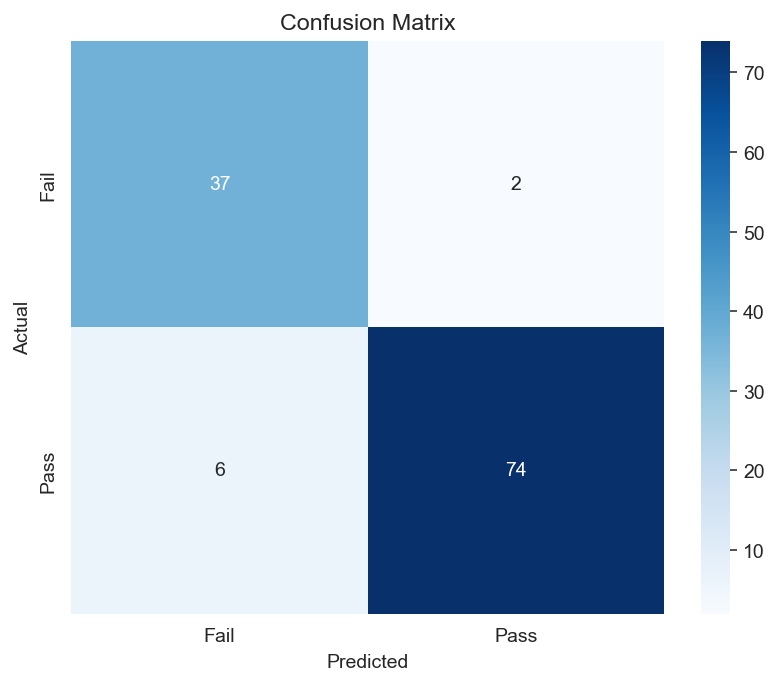

In [18]:
accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f'Accuracy: {accuracy * 100:.2f}%')
print('\nConfusion Matrix:')
print(cm)
print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=['Fail', 'Pass']))

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Fail', 'Pass'], yticklabels=['Fail', 'Pass'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

### Feature Importance

,Feature,Importance
31,G2,0.830099
30,G1,0.033541
12,traveltime,0.033180
2,age,0.029862
27,Walc,0.026425
11,guardian,0.017962
8,Mjob,0.017595
9,Fjob,0.008052
25,goout,0.003284
26,Dalc,0.000000


/var/folders/27/scw6zr8d4j1gp14h3xdf_kjc0000gn/T/ipykernel_21742/3556424287.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance.head(10), x='Importance', y='Feature', palette='viridis')


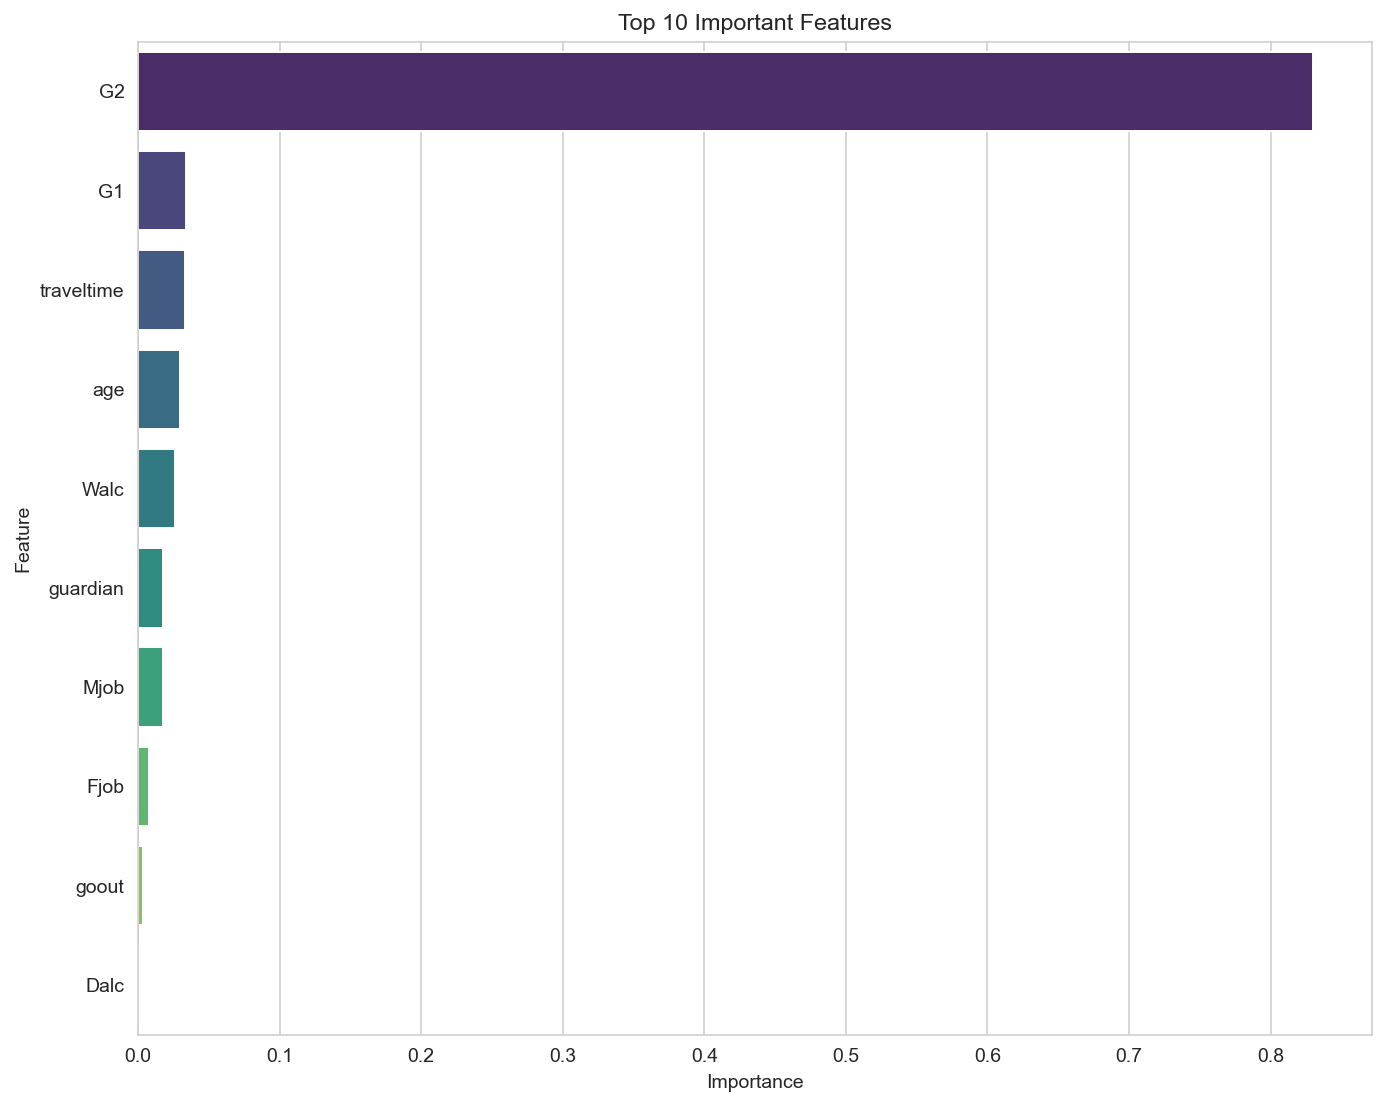

In [19]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt_classifier.feature_importances_
}).sort_values(by='Importance', ascending=False)

display(feature_importance.head(10))

plt.figure(figsize=(10, 8))
sns.barplot(data=feature_importance.head(10), x='Importance', y='Feature', palette='viridis')
plt.title('Top 10 Important Features')
plt.tight_layout()
plt.show()

### Visualize Decision Tree

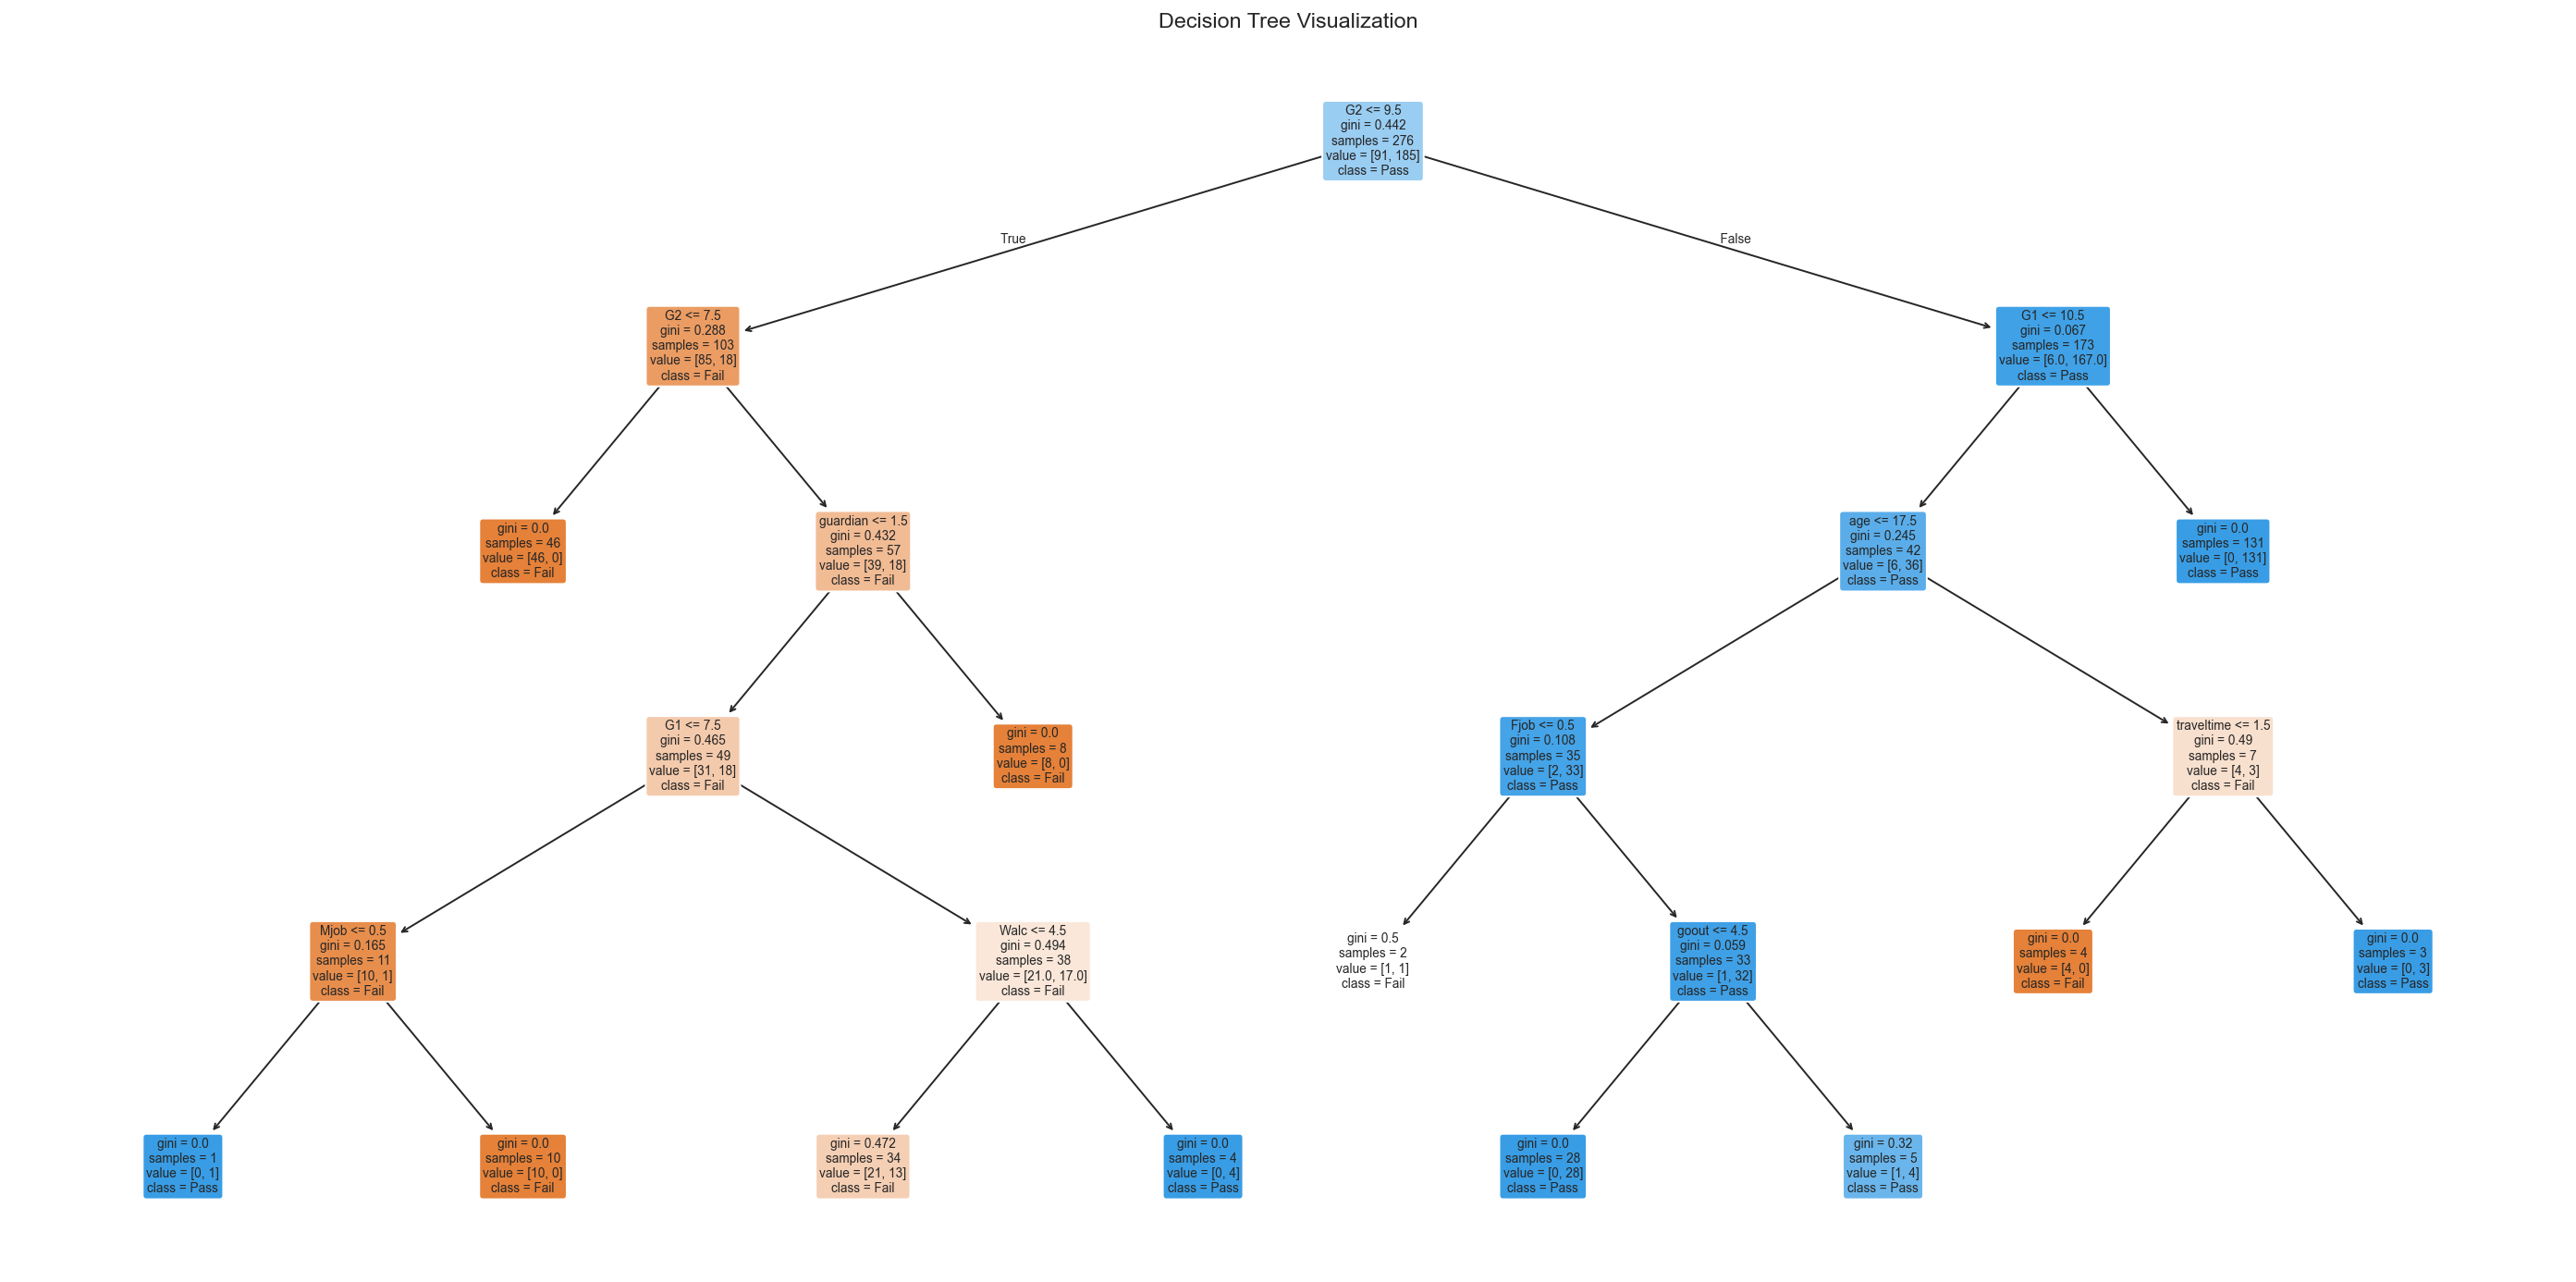

In [20]:
plt.figure(figsize=(20, 10))
plot_tree(
    dt_classifier,
    feature_names=list(X.columns),
    class_names=['Fail', 'Pass'],
    filled=True,
    rounded=True,
    fontsize=7
)
plt.title('Decision Tree Visualization')
plt.tight_layout()
plt.show()